# Pipeline Tag Prediction
## Comparative EDA - Untagged Model Cards

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook compares the predictions made by the three trained models (baseline TF-IDF + Logistic Regression, RoBERTa-base, ModernBERT-base) on the model cards that were missing a `pipeline_tag` on Hugging Face. It runs in this order:

1. Load predicted datasets
2. Merge and overview
3. Predicted tag distribution by model (top 10 vs. other)
4. Confidence analysis for top 10 tags
5. Model agreement analysis
6. Predictions outside the top 10 tags
7. Lowest confidence tags
8. Text length for lowest confidence predictions
9. Comparison against training set tag distribution
10. Save summary outputs

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

# Plot defaults, kept consistent with the baseline/roberta/modernbert notebooks
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Predicted Datasets

Loads the three prediction files from Drive. Each one has the same schema: `modelId`, `predicted_tag`, `confidence_pct`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'

baseline_df = pd.read_parquet(f'{DRIVE_DIR}/untagged_model_cards_predicted_baseline.parquet')
roberta_df = pd.read_parquet(f'{DRIVE_DIR}/untagged_model_cards_predicted_roberta.parquet')
modernbert_df = pd.read_parquet(f'{DRIVE_DIR}/untagged_model_cards_predicted_modernbert.parquet')

for name, df in [('baseline', baseline_df), ('roberta', roberta_df), ('modernbert', modernbert_df)]:
    print(f'{name}: {df.shape}')

Mounted at /content/drive
baseline: (115620, 4)
roberta: (115620, 4)
modernbert: (115620, 4)


In [3]:
# Standardize column names across the three files in case of small naming differences
for df in [baseline_df, roberta_df, modernbert_df]:
    df.columns = [c.strip() for c in df.columns]

baseline_df.head()

,modelId,card_text_clean,predicted_tag,confidence_pct
0,DreadPoor/Kitsch_Late_ALT-TEST-Q5_K_M-GGUF,dreadpoor kitsch late alt test q k m gguf imag...,image-text-to-text,42.78
1,namlevan888/blockassist-bc-lethal_durable_rave...,gensyn blockassist gensyn s blockassist is a d...,text-generation,30.50
2,ElenaSenger/career-path-representation-mpnet-d...,career path representation mpnet decorte this ...,sentence-similarity,87.87
3,priorcomputers/llama-3.2-1b-instruct-cn-dat-kr...,llama b instruct cn dat kr a creative this is ...,text-generation,97.08
4,mradermacher/ACC-Qwen3-30B-A3B-i1-GGUF,about quantize version output tensor quantised...,text-generation,43.50


## 2. Merge and Overview

Two versions of the merged data are built:

- **long_df**: one row per (modelId, model, predicted_tag, confidence_pct), used for distribution and confidence comparisons.
- **wide_df**: one row per modelId, with each model's predicted tag and confidence as separate columns, used for agreement analysis.

In [4]:
# Loaded from metadata.json so this can't drift from what the models were actually trained on.
# NOTE: this was previously a hardcoded list that incorrectly included reinforcement-learning
# and any-to-any (dropped during data cleaning in NH_data_cleaning.ipynb -- they are outside
# all three models' label space, so they can never appear as a prediction) and omitted
# sentence-similarity and image-classification (which the models CAN and do predict). That bug
# caused sentence-similarity/image-classification predictions to be silently folded into "other"
# everywhere below, and made reinforcement-learning/any-to-any look like modeling failures
# (0 predictions, NaN confidence) when they were actually just never valid outputs.
import json

try:
    with open(f'{DRIVE_DIR}/metadata.json') as f:
        _metadata = json.load(f)
    _id2label = _metadata['id2label']
    TOP_10_TAGS = [_id2label[str(i)] for i in range(len(_id2label))]
    print('Loaded TOP_10_TAGS from metadata.json:', TOP_10_TAGS)
except (FileNotFoundError, KeyError) as e:
    # Fallback: matches the label2id the baseline/RoBERTa/ModernBERT models were actually
    # trained on (see NH_data_cleaning.ipynb and 00_NB_Baseline_Final.ipynb cell 7 output).
    TOP_10_TAGS = [
        'text-generation', 'text-to-image', 'image-text-to-text', 'text-classification',
        'translation', 'automatic-speech-recognition', 'token-classification', 'robotics',
        'sentence-similarity', 'image-classification'
    ]
    print(f'metadata.json not available ({e}); using fallback TOP_10_TAGS:', TOP_10_TAGS)

MODEL_ORDER = ['baseline', 'roberta', 'modernbert']

baseline_df['model'] = 'baseline'
roberta_df['model'] = 'roberta'
modernbert_df['model'] = 'modernbert'

long_df = pd.concat([baseline_df, roberta_df, modernbert_df], ignore_index=True)
long_df['model'] = pd.Categorical(long_df['model'], categories=MODEL_ORDER, ordered=True)
long_df['in_top10'] = long_df['predicted_tag'].isin(TOP_10_TAGS)

print('long_df shape:', long_df.shape)
long_df.head()

Loaded TOP_10_TAGS from metadata.json: ['automatic-speech-recognition', 'image-classification', 'image-text-to-text', 'robotics', 'sentence-similarity', 'text-classification', 'text-generation', 'text-to-image', 'token-classification', 'translation']
long_df shape: (346860, 6)


,modelId,card_text_clean,predicted_tag,confidence_pct,model,in_top10
0,DreadPoor/Kitsch_Late_ALT-TEST-Q5_K_M-GGUF,dreadpoor kitsch late alt test q k m gguf imag...,image-text-to-text,42.78,baseline,True
1,namlevan888/blockassist-bc-lethal_durable_rave...,gensyn blockassist gensyn s blockassist is a d...,text-generation,30.50,baseline,True
2,ElenaSenger/career-path-representation-mpnet-d...,career path representation mpnet decorte this ...,sentence-similarity,87.87,baseline,True
3,priorcomputers/llama-3.2-1b-instruct-cn-dat-kr...,llama b instruct cn dat kr a creative this is ...,text-generation,97.08,baseline,True
4,mradermacher/ACC-Qwen3-30B-A3B-i1-GGUF,about quantize version output tensor quantised...,text-generation,43.50,baseline,True


In [5]:
# Wide format: one row per modelId, columns per model
wide_df = (
    baseline_df[['modelId', 'predicted_tag', 'confidence_pct']]
    .rename(columns={'predicted_tag': 'tag_baseline', 'confidence_pct': 'conf_baseline'})
    .merge(
        roberta_df[['modelId', 'predicted_tag', 'confidence_pct']]
        .rename(columns={'predicted_tag': 'tag_roberta', 'confidence_pct': 'conf_roberta'}),
        on='modelId', how='outer'
    )
    .merge(
        modernbert_df[['modelId', 'predicted_tag', 'confidence_pct']]
        .rename(columns={'predicted_tag': 'tag_modernbert', 'confidence_pct': 'conf_modernbert'}),
        on='modelId', how='outer'
    )
)

print('wide_df shape:', wide_df.shape)
missing_any = wide_df[['tag_baseline', 'tag_roberta', 'tag_modernbert']].isna().any(axis=1).sum()
print(f'Rows missing a prediction from at least one model: {missing_any}')
wide_df.head()

wide_df shape: (115620, 7)
Rows missing a prediction from at least one model: 0


,modelId,tag_baseline,conf_baseline,tag_roberta,conf_roberta,tag_modernbert,conf_modernbert
0,0001AMA/a-akuoko,image-classification,62.84,image-text-to-text,85.54,image-text-to-text,97.28
1,0001AMA/a-akuoko-machine-intelligence,image-classification,64.98,image-text-to-text,81.59,image-text-to-text,96.87
2,0001AMA/ama-akuoko,image-classification,62.84,image-text-to-text,85.28,image-text-to-text,96.83
3,0001AMA/ama-akuoko-machine-intelligence,image-classification,64.98,image-text-to-text,79.75,image-text-to-text,96.61
4,0001AMA/ama-akuoko-spad,image-classification,66.02,image-text-to-text,90.02,image-text-to-text,97.48


In [6]:
# Basic overview: nulls and confidence summary per model
print('Null counts by model:')
print(long_df.groupby('model', observed=True)[['predicted_tag', 'confidence_pct']].apply(lambda x: x.isna().sum()))
print()
print('Confidence summary by model:')
long_df.groupby('model', observed=True)['confidence_pct'].describe()

Null counts by model:
            predicted_tag  confidence_pct
model                                    
baseline                0               0
roberta                 0               0
modernbert              0               0

Confidence summary by model:


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
baseline,115620.0,63.595837,24.901461,14.14,39.81,64.09,88.36,100.00
roberta,115620.0,89.402844,15.849872,19.26,85.46,97.86,99.58,99.91
modernbert,115620.0,90.936266,15.127038,20.29,89.28,98.76,99.88,100.00


## 3. Predicted Tag Distribution by Model

How often each model predicts a top 10 tag versus a tag outside the top 10 list, and the shape of the predicted tag distribution per model.

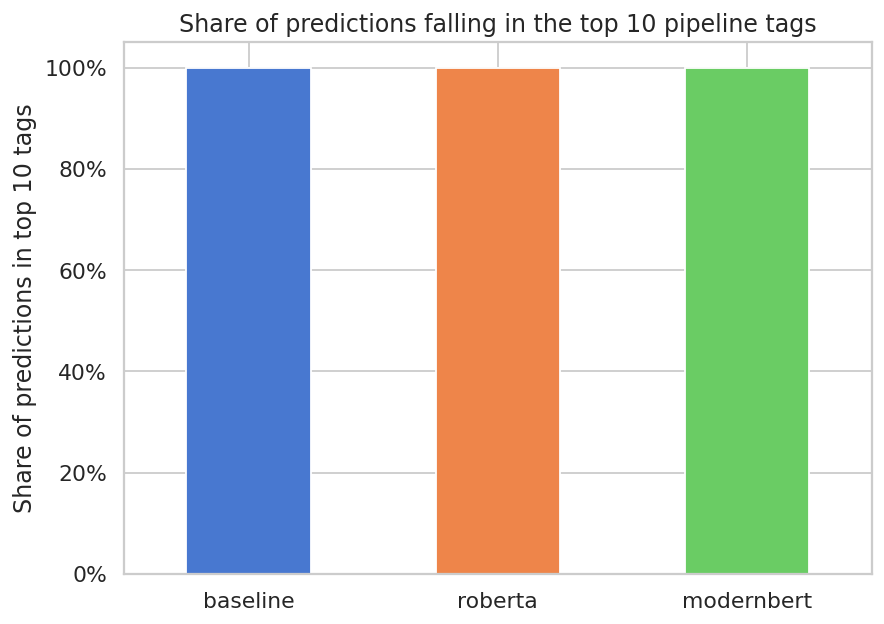

In [7]:
top10_share = long_df.groupby('model', observed=True)['in_top10'].mean().reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
top10_share.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 3))
ax.set_ylabel('Share of predictions in top 10 tags')
ax.set_xlabel('')
ax.set_title('Share of predictions falling in the top 10 pipeline tags')
ax.set_xticklabels(MODEL_ORDER, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR}/eda_top10_share_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

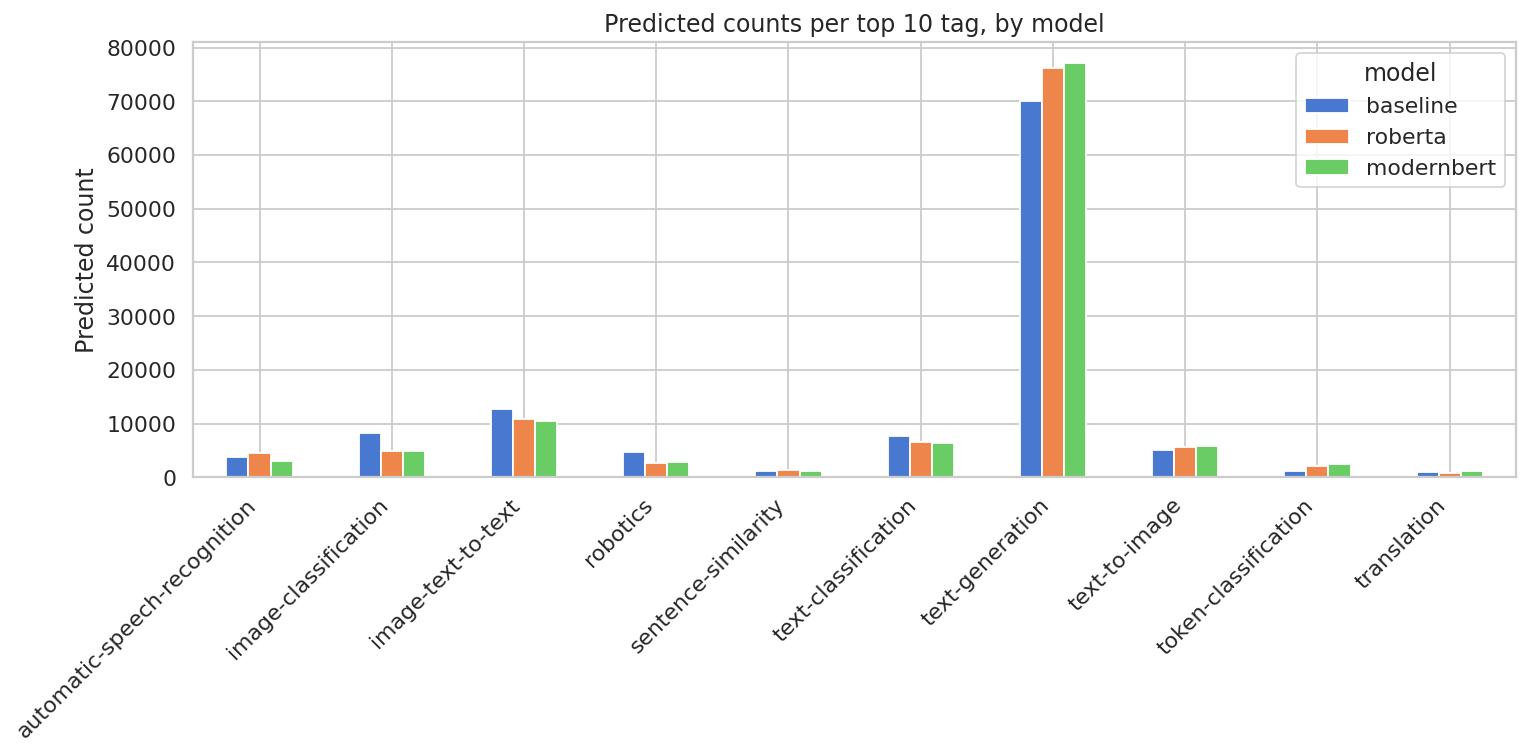

model,baseline,roberta,modernbert
predicted_tag,,,
automatic-speech-recognition,3809,4451,3051
image-classification,8163,4878,4900
image-text-to-text,12758,10899,10549
robotics,4682,2684,2794
sentence-similarity,1198,1299,1176
text-classification,7710,6630,6395
text-generation,70027,76206,77114
text-to-image,5160,5657,5832
token-classification,1097,2092,2548


In [8]:
# Full predicted tag distribution per model, restricted to the top 10 tags for readability
top10_counts = (
    long_df[long_df['in_top10']]
    .groupby(['model', 'predicted_tag'], observed=True)
    .size()
    .reset_index(name='count')
)

pivot_counts = top10_counts.pivot(index='predicted_tag', columns='model', values='count').reindex(TOP_10_TAGS)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 3))
ax.set_ylabel('Predicted count')
ax.set_xlabel('')
ax.set_title('Predicted counts per top 10 tag, by model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR}/eda_top10_counts_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

pivot_counts

## 4. Confidence Analysis for Top 10 Tags

How confident each model is when it predicts each of the top 10 tags. This is a proxy for how well each model performs per class, since the untagged set has no ground truth labels to score against directly.

In [9]:
conf_by_tag = (
    long_df[long_df['in_top10']]
    .groupby(['predicted_tag', 'model'], observed=True)['confidence_pct']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)

conf_summary = conf_by_tag.pivot(index='predicted_tag', columns='model', values='mean').reindex(TOP_10_TAGS)
conf_summary

model,baseline,roberta,modernbert
predicted_tag,,,
automatic-speech-recognition,64.246773,90.799292,89.763484
image-classification,54.432355,85.589744,85.674024
image-text-to-text,66.090667,82.383132,84.052009
robotics,52.952736,83.988607,80.392147
sentence-similarity,66.085985,86.840246,85.267568
text-classification,59.919690,84.848478,85.063167
text-generation,64.570706,91.618786,93.572494
text-to-image,73.068641,92.101048,91.509053
token-classification,63.211705,67.723446,82.619568


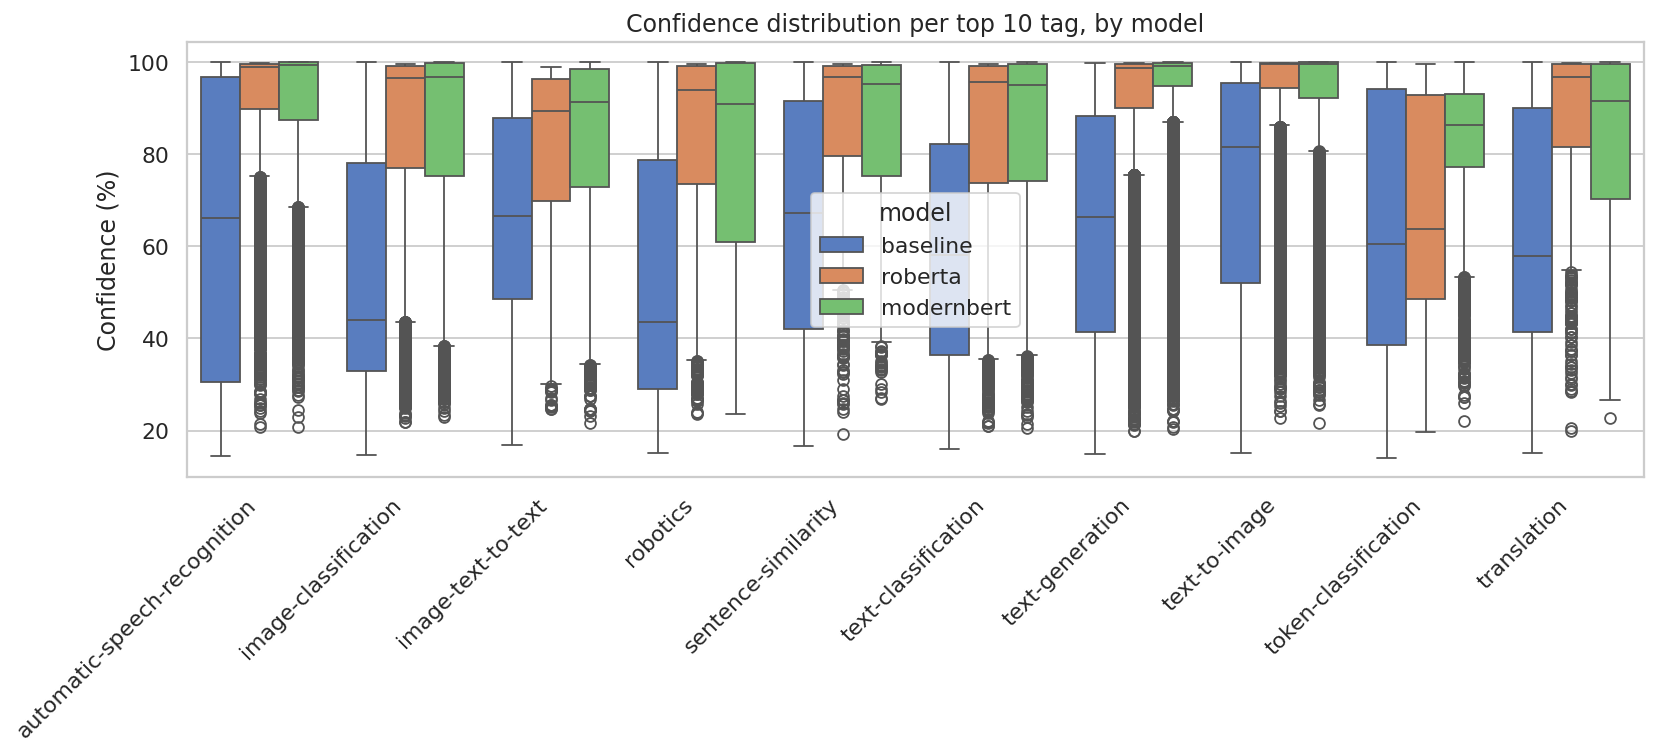

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=long_df[long_df['in_top10']],
    x='predicted_tag', y='confidence_pct', hue='model',
    order=TOP_10_TAGS, hue_order=MODEL_ORDER, ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Confidence (%)')
ax.set_title('Confidence distribution per top 10 tag, by model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR}/eda_confidence_boxplot_top10.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Agreement Analysis

Since there is no ground truth for the untagged set, agreement between models is a useful second signal. High agreement plus high confidence on a tag is a reasonable indicator of a reliable prediction. Disagreement points to model cards worth a closer look.

In [11]:
pairs = list(combinations(MODEL_ORDER, 2))
agreement_rates = {}

for m1, m2 in pairs:
    col1, col2 = f'tag_{m1}', f'tag_{m2}'
    valid = wide_df[[col1, col2]].dropna()
    rate = (valid[col1] == valid[col2]).mean()
    agreement_rates[f'{m1} vs {m2}'] = rate

agreement_df = pd.Series(agreement_rates, name='agreement_rate').to_frame()
agreement_df['agreement_rate'] = agreement_df['agreement_rate'].round(4)
agreement_df

,agreement_rate
baseline vs roberta,0.7936
baseline vs modernbert,0.8016
roberta vs modernbert,0.8698


In [12]:
# Full three-way agreement
all_valid = wide_df[['tag_baseline', 'tag_roberta', 'tag_modernbert']].dropna()
all_agree = (
    (all_valid['tag_baseline'] == all_valid['tag_roberta']) &
    (all_valid['tag_roberta'] == all_valid['tag_modernbert'])
).mean()
print(f'All three models agree on: {all_agree:.2%} of model cards with a prediction from all three')

All three models agree on: 74.91% of model cards with a prediction from all three


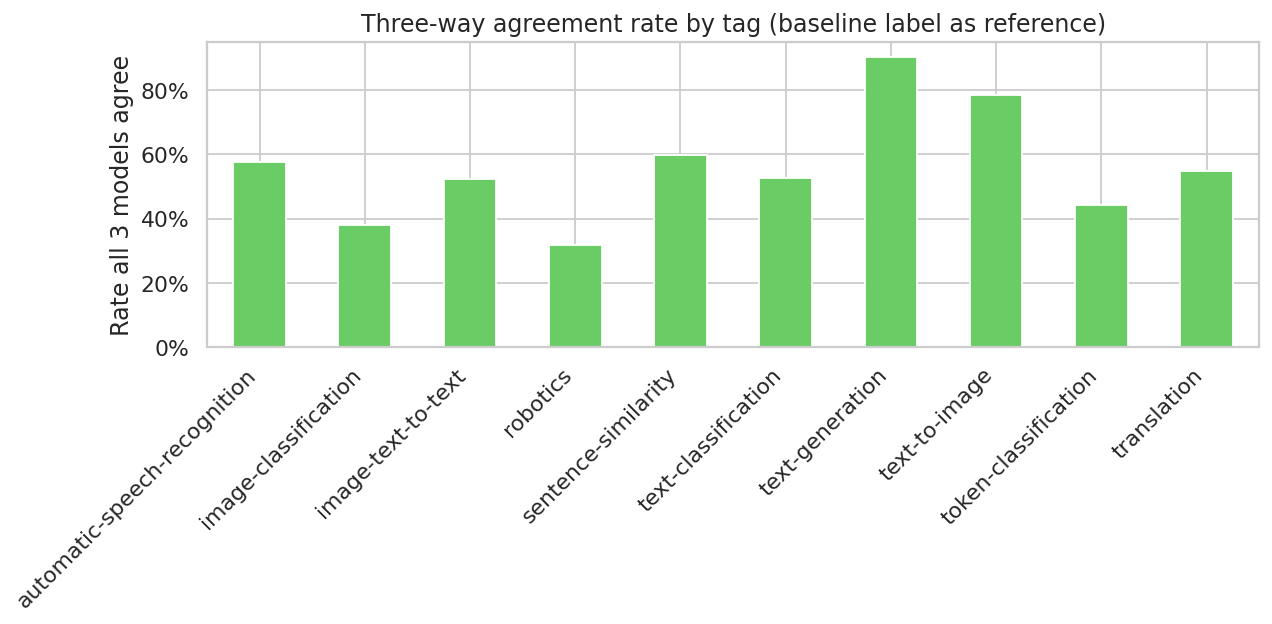

In [13]:
# Agreement rate broken down by baseline-predicted tag, restricted to top 10 tags
wide_top10 = wide_df[wide_df['tag_baseline'].isin(TOP_10_TAGS)].copy()
wide_top10['agree_all'] = (
    (wide_top10['tag_baseline'] == wide_top10['tag_roberta']) &
    (wide_top10['tag_roberta'] == wide_top10['tag_modernbert'])
)

agree_by_tag = wide_top10.groupby('tag_baseline', observed=True)['agree_all'].mean().reindex(TOP_10_TAGS)

fig, ax = plt.subplots(figsize=(10, 5))
agree_by_tag.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[2])
ax.set_ylabel('Rate all 3 models agree')
ax.set_xlabel('')
ax.set_title('Three-way agreement rate by tag (baseline label as reference)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR}/eda_agreement_by_tag.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Predictions Outside the Top 10 Tags

How each model handles model cards that likely belong to one of the smaller, non-top-10 categories, and whether confidence drops on those predictions.

In [14]:
other_df = long_df[~long_df['in_top10']]

print('Share of predictions outside top 10, by model:')
print((1 - top10_share).round(4))
print()
print('Confidence on out-of-top-10 predictions, by model:')
other_df.groupby('model', observed=True)['confidence_pct'].describe()[['mean', '50%', 'std']]

Share of predictions outside top 10, by model:
model
baseline      0.0
roberta       0.0
modernbert    0.0
Name: in_top10, dtype: float64

Confidence on out-of-top-10 predictions, by model:


,mean,50%,std


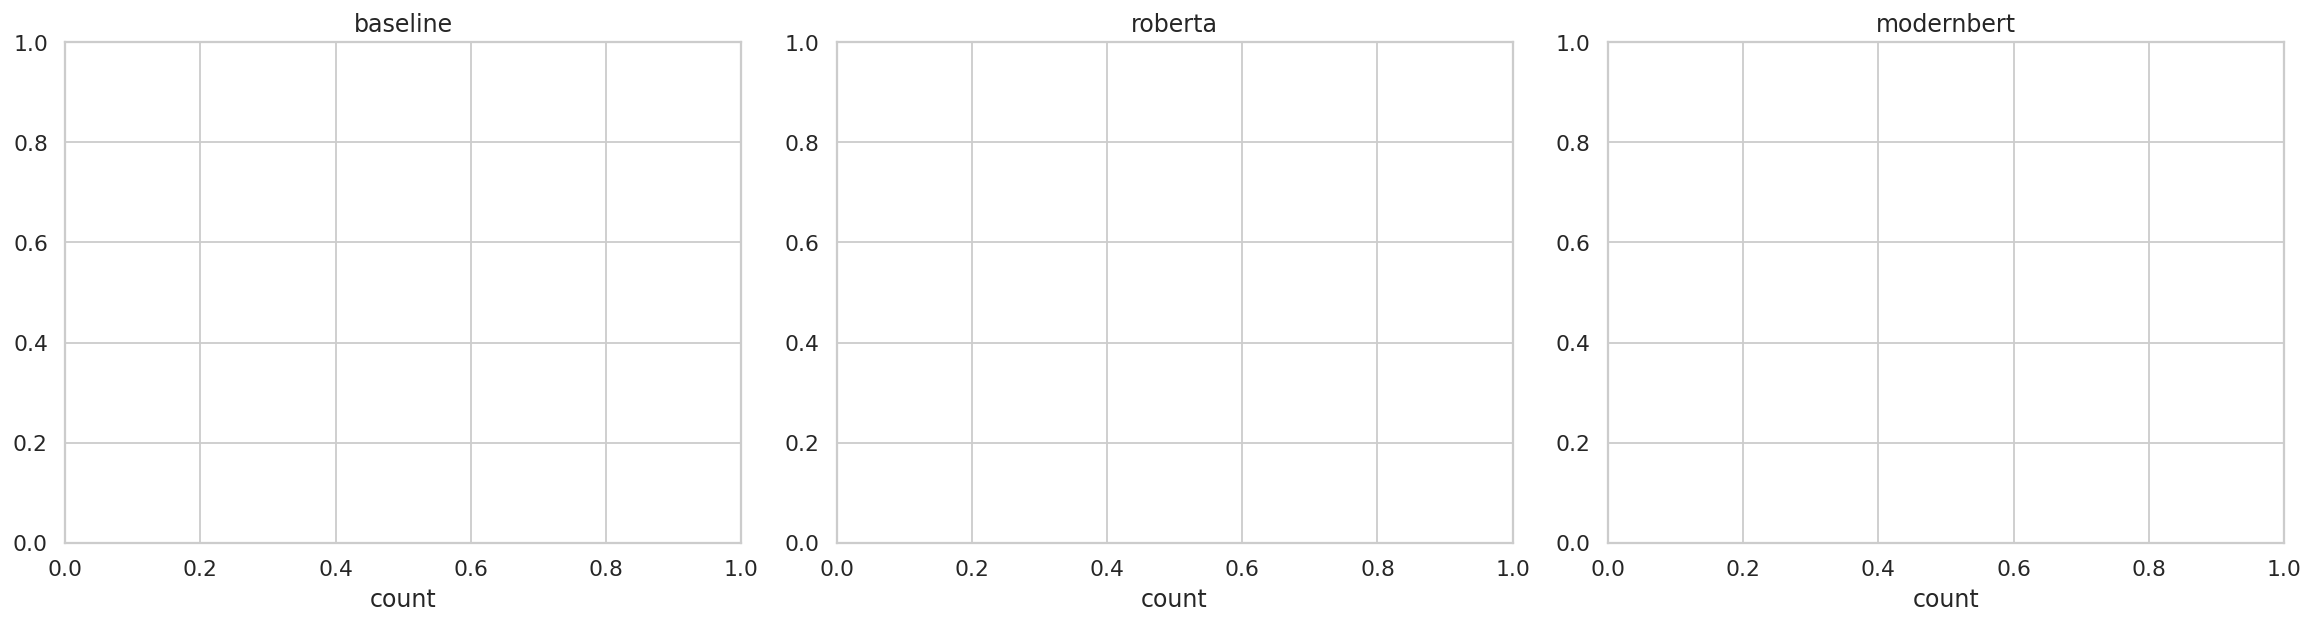

In [15]:
# Most common non-top-10 tags per model
other_top = (
    other_df.groupby(['model', 'predicted_tag'], observed=True)
    .size()
    .reset_index(name='count')
    .sort_values(['model', 'count'], ascending=[True, False])
    .groupby('model', observed=True)
    .head(10)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, m in zip(axes, MODEL_ORDER):
    sub = other_top[other_top['model'] == m]
    sns.barplot(data=sub, y='predicted_tag', x='count', ax=ax, color=sns.color_palette('muted')[0])
    ax.set_title(m)
    ax.set_ylabel('')
    ax.set_xlabel('count')
plt.tight_layout()
fig.savefig(f'{DRIVE_DIR}/eda_top_other_tags_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Lowest Confidence Tags

Tags with the lowest mean confidence per model, across all predicted tags (not just the top 10). These are the tags where each model is least sure, and a good starting point for error analysis.

In [16]:
N_LOWEST = 10

lowest_by_model = {}
for m in MODEL_ORDER:
    sub = long_df[long_df['model'] == m]
    tag_conf = sub.groupby('predicted_tag')['confidence_pct'].agg(['mean', 'count'])
    tag_conf = tag_conf[tag_conf['count'] >= 5]  # ignore tags with too few predictions to be meaningful
    lowest_by_model[m] = tag_conf.sort_values('mean').head(N_LOWEST)
    print(f'\n{m} - {N_LOWEST} lowest-confidence tags (min 5 predictions):')
    print(lowest_by_model[m])


baseline - 10 lowest-confidence tags (min 5 predictions):
                                   mean  count
predicted_tag                                 
robotics                      52.952736   4682
image-classification          54.432355   8163
text-classification           59.919690   7710
translation                   62.570748   1016
token-classification          63.211705   1097
automatic-speech-recognition  64.246773   3809
text-generation               64.570706  70027
sentence-similarity           66.085985   1198
image-text-to-text            66.090667  12758
text-to-image                 73.068641   5160

roberta - 10 lowest-confidence tags (min 5 predictions):
                                   mean  count
predicted_tag                                 
token-classification          67.723446   2092
image-text-to-text            82.383132  10899
robotics                      83.988607   2684
text-classification           84.848478   6630
image-classification          85.5897

In [17]:
# Union of the lowest-confidence tags across all three models, used in the next section
lowest_tags_union = sorted(set().union(*[set(v.index) for v in lowest_by_model.values()]))
print(f'{len(lowest_tags_union)} distinct tags in the low-confidence union:')
print(lowest_tags_union)

10 distinct tags in the low-confidence union:
['automatic-speech-recognition', 'image-classification', 'image-text-to-text', 'robotics', 'sentence-similarity', 'text-classification', 'text-generation', 'text-to-image', 'token-classification', 'translation']


## 8. Text Length for Lowest Confidence Predictions

Checks whether the low-confidence predictions from Section 7 tend to come from unusually short or unusually long model cards. This requires the raw model card text for the untagged set, so it loads the untagged card text file separately. Update `TEXT_FILE` and `TEXT_COLUMN` below if the file name or column name differs from what's used here.

In [18]:
# Adjust these two lines if the file name or text column differs
TEXT_FILE = f'{DRIVE_DIR}/model_cards_untagged_cleaned.parquet'
TEXT_COLUMN = 'text'  # e.g. could be 'text', 'cardData', 'content', or similar

try:
    text_df = pd.read_parquet(TEXT_FILE)
    print('Loaded:', TEXT_FILE)
    print('Columns:', list(text_df.columns))
except FileNotFoundError:
    text_df = None
    print(f'{TEXT_FILE} not found. Update TEXT_FILE above to point at the raw untagged model card data.')

Loaded: /content/drive/MyDrive/266-pipeline-tag-prediction/model_cards_untagged_cleaned.parquet
Columns: ['modelId', 'text', 'char_len', 'word_count']


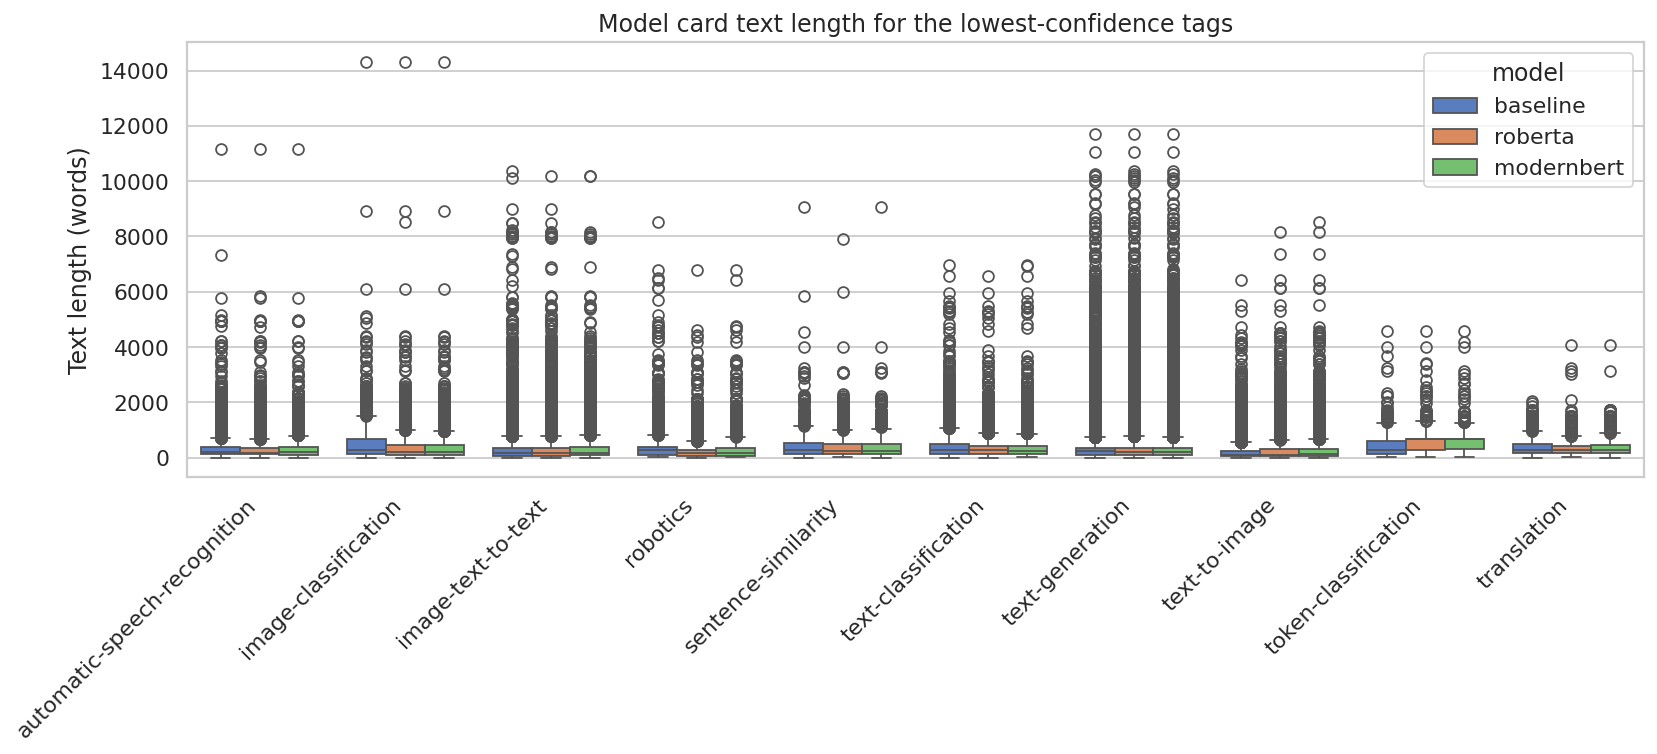

Median text length, low-confidence tags vs. overall:
Low-confidence tags: 208.0
All predictions: 208.0


In [19]:
if text_df is not None:
    if TEXT_COLUMN not in text_df.columns:
        raise ValueError(f"'{TEXT_COLUMN}' not in columns: {list(text_df.columns)}. Update TEXT_COLUMN above.")

    text_df['text_length'] = text_df[TEXT_COLUMN].astype(str).str.split().str.len()
    text_len_lookup = text_df[['modelId', 'text_length']].drop_duplicates('modelId')

    len_df = long_df.merge(text_len_lookup, on='modelId', how='left')
    low_conf_len = len_df[len_df['predicted_tag'].isin(lowest_tags_union)]

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(
        data=low_conf_len, x='predicted_tag', y='text_length', hue='model',
        order=lowest_tags_union, hue_order=MODEL_ORDER, ax=ax
    )
    ax.set_xlabel('')
    ax.set_ylabel('Text length (words)')
    ax.set_title('Model card text length for the lowest-confidence tags')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fig.savefig(f'{DRIVE_DIR}/eda_textlen_low_confidence_tags.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Median text length, low-confidence tags vs. overall:')
    print('Low-confidence tags:', low_conf_len['text_length'].median())
    print('All predictions:', len_df['text_length'].median())

## 9. Comparison Against Training Set Tag Distribution

Compares the predicted tag distribution on the untagged set to the true tag distribution in the training data (`model_cards_cleaned.parquet`). A large shift would suggest the untagged set skews toward different categories than what the models were trained on, which matters for how much to trust the predictions.

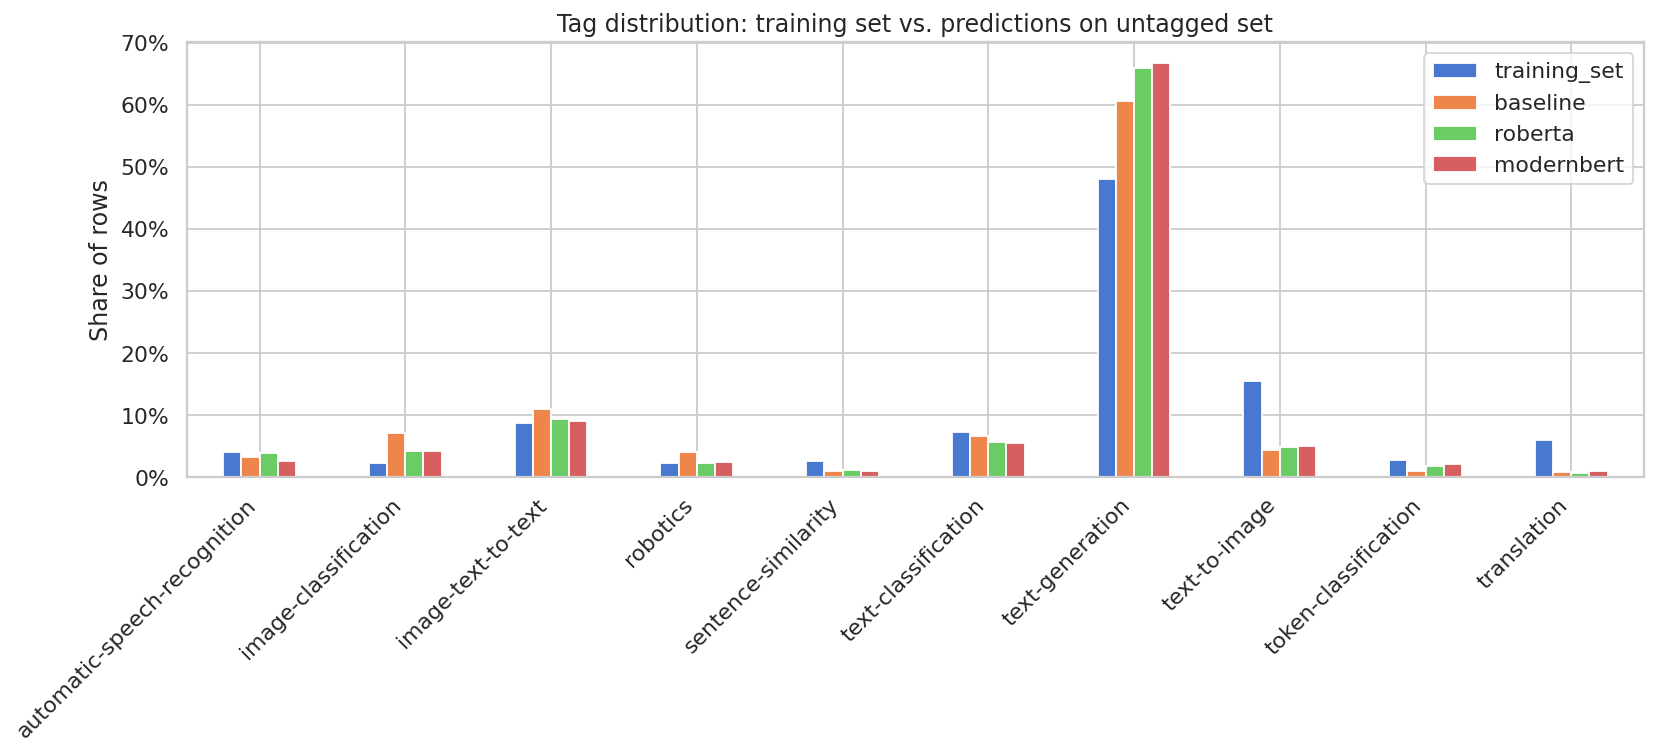

In [20]:
try:
    train_dist_df = pd.read_parquet(f'{DRIVE_DIR}/model_cards_cleaned.parquet')
    train_tag_dist = train_dist_df['pipeline_tag'].value_counts(normalize=True).reindex(TOP_10_TAGS)

    pred_tag_dist = {}
    for m in MODEL_ORDER:
        sub = long_df[long_df['model'] == m]
        pred_tag_dist[m] = sub['predicted_tag'].value_counts(normalize=True).reindex(TOP_10_TAGS)

    dist_compare = pd.DataFrame({'training_set': train_tag_dist, **pred_tag_dist})

    fig, ax = plt.subplots(figsize=(13, 6))
    dist_compare.plot(kind='bar', ax=ax)
    ax.set_ylabel('Share of rows')
    ax.set_xlabel('')
    ax.set_title('Tag distribution: training set vs. predictions on untagged set')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    fig.savefig(f'{DRIVE_DIR}/eda_train_vs_predicted_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    dist_compare
except FileNotFoundError:
    print('model_cards_cleaned.parquet not found in DRIVE_DIR, skipping this comparison.')

## 10. Save Summary Outputs

Saves the key summary tables to Drive so they can be pulled into the writeup without re-running the notebook.

In [21]:
conf_summary.to_csv(f'{DRIVE_DIR}/eda_confidence_by_top10_tag.csv')
agreement_df.to_csv(f'{DRIVE_DIR}/eda_pairwise_agreement.csv')
agree_by_tag.to_csv(f'{DRIVE_DIR}/eda_threeway_agreement_by_tag.csv')

for m in MODEL_ORDER:
    lowest_by_model[m].to_csv(f'{DRIVE_DIR}/eda_lowest_confidence_tags_{m}.csv')

print('Summary tables saved to', DRIVE_DIR)

Summary tables saved to /content/drive/MyDrive/266-pipeline-tag-prediction
